# Collaborative Filtering

## Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import (
    train_test_split as surprise_split,
    cross_validate,
    GridSearchCV
)
import surprise

## Load & Split Data

In [2]:
ratings = pd.read_csv('../data/ratings_clean.csv')
movies  = pd.read_csv('../data/movies_clean.csv')

train_df, test_df = train_test_split(ratings, test_size=0.20, random_state=42)

print(f'Total ratings : {len(ratings):,}')
print(f'Train split   : {len(train_df):,} ratings')
print(f'Test split    : {len(test_df):,} ratings')
print(f'Users         : {ratings["userId"].nunique()}')
print(f'Movies        : {ratings["movieId"].nunique()}')

Total ratings : 100,836
Train split   : 80,668 ratings
Test split    : 20,168 ratings
Users         : 610
Movies        : 9724


## Build Surprise Dataset

In [3]:
reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

print('Surprise Dataset created successfully.')
print(f'  Rating scale : 0.5 – 5.0')
print(f'  Rows : {len(ratings):,}')

Surprise Dataset created successfully.
  Rating scale : 0.5 – 5.0
  Rows : 100,836


## 5-Fold Cross-Validation

In [4]:
svd_cv = SVD(
    n_factors  = 100,
    n_epochs   = 20,
    lr_all     = 0.005,
    reg_all    = 0.02,
    random_state = 42
)

cv_results = cross_validate(
    svd_cv,
    data,
    measures = ['RMSE', 'MAE'],
    cv       = 5,
    verbose  = True
)

print(f"Cross-Validation Summary")
print(f"  RMSE : {cv_results['test_rmse'].mean():.4f}  ±  {cv_results['test_rmse'].std():.4f}")
print(f"  MAE  : {cv_results['test_mae'].mean():.4f}  ±  {cv_results['test_mae'].std():.4f}")

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8854  0.8709  0.8769  0.8713  0.8680  0.8745  0.0062  
MAE (testset)     0.6778  0.6708  0.6724  0.6709  0.6668  0.6717  0.0036  
Fit time          1.39    2.16    1.58    1.41    1.17    1.54    0.34    
Test time         0.20    0.33    0.18    0.10    0.09    0.18    0.09    
Cross-Validation Summary
  RMSE : 0.8745  ±  0.0062
  MAE  : 0.6717  ±  0.0036


## Hyperparameter Tuning — GridSearchCV

In [5]:
param_grid = {
    'n_factors' : [50, 100],
    'n_epochs'  : [20],
    'lr_all'    : [0.005],
    'reg_all'   : [0.02, 0.05]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print('Best RMSE score  :', round(gs.best_score['rmse'], 4))
print('Best params      :', gs.best_params['rmse'])

Best RMSE score  : 0.8748
Best params      : {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}


## Train Final SVD Model

In [6]:
best_params = gs.best_params['rmse']

trainset_surprise, testset_surprise = surprise_split(data, test_size=0.20, random_state=42)

svd = SVD(
    n_factors    = best_params['n_factors'],
    n_epochs     = best_params['n_epochs'],
    lr_all       = best_params['lr_all'],
    reg_all      = best_params['reg_all'],
    random_state = 42,
    verbose      = True
)

svd.fit(trainset_surprise)
print('\nTraining complete.')

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

Training complete.


## Evaluate — RMSE & MAE on Test Set

In [7]:
predictions = svd.test(testset_surprise)

rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions,  verbose=False)

print(f'Test RMSE    : {rmse:.4f}')
print(f'Test MAE     : {mae:.4f}')
print(f'Interpretation: On average, predicted ratings are off by {mae:.2f} stars')

Test RMSE    : 0.8759
Test MAE     : 0.6733
Interpretation: On average, predicted ratings are off by 0.67 stars


## Plot — Predicted vs Actual Ratings

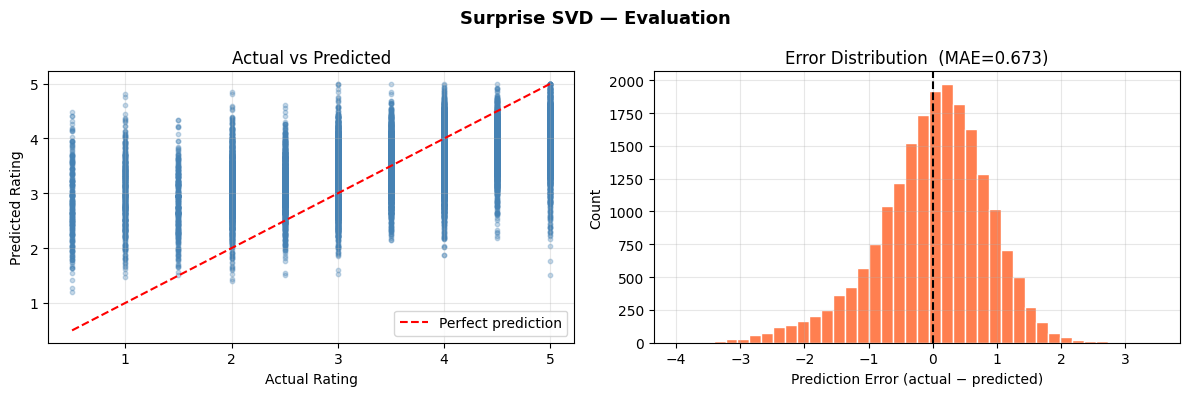

In [8]:
actuals    = np.array([p.r_ui for p in predictions])
predicted  = np.array([p.est  for p in predictions])
errors     = actuals - predicted

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(actuals, predicted, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0.5, 5], [0.5, 5], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(errors, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Prediction Error (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Error Distribution  (MAE={mae:.3f})')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Surprise SVD — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Top-N Evaluation

In [9]:
np.random.seed(42)
all_movie_ids = ratings['movieId'].unique()
sample_users  = np.random.choice(
    ratings['userId'].unique(),
    size=min(100, ratings['userId'].nunique()),
    replace=False
)

precisions, recalls, f1s = [], [], []

for uid in sample_users:
    seen  = set(ratings[ratings['userId'] == uid]['movieId'])
    liked = set(test_df[
        (test_df['userId'] == uid) & (test_df['rating'] >= 4.0)
    ]['movieId'])

    if not liked:
        continue

    unseen  = [m for m in all_movie_ids if m not in seen]
    # Use surprise's predict() — returns a Prediction namedtuple
    preds_u = [(m, svd.predict(uid, m).est) for m in unseen]
    top10   = set(m for m, _ in sorted(preds_u, key=lambda x: x[1], reverse=True)[:10])

    hits      = len(top10 & liked)
    precision = hits / 10
    recall    = hits / len(liked)
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)

print('Collaborative Filtering (Surprise SVD) — Top-N Evaluation')
print(f'Relevance criterion : user rated movie >= 4.0 in test set')
print(f'Users evaluated : {len(precisions)}')
print(f'Precision@10 : {np.mean(precisions):.4f}')
print(f'Recall@10 : {np.mean(recalls):.4f}')
print(f'F1@10 : {np.mean(f1s):.4f}')

Collaborative Filtering (Surprise SVD) — Top-N Evaluation
Relevance criterion : user rated movie >= 4.0 in test set
Users evaluated : 99
Precision@10 : 0.0000
Recall@10 : 0.0000
F1@10 : 0.0000


## Sample Predictions — Single User

In [10]:
uid = 1
seen_by_user = set(ratings[ratings['userId'] == uid]['movieId'])
unseen_movies = [m for m in all_movie_ids if m not in seen_by_user]

preds_uid1 = [
    (movies[movies['movieId'] == m]['title'].values[0],
     movies[movies['movieId'] == m]['genres'].values[0],
     round(svd.predict(uid, m).est, 3))
    for m in unseen_movies
    if len(movies[movies['movieId'] == m]) > 0
]

preds_uid1.sort(key=lambda x: x[2], reverse=True)

print(f'Top-10 predicted movies for User {uid}:')
print(f'{"Rank":<5} {"Title":<45} {"Genres":<35} {"Predicted Rating"}')
print('-' * 100)
for rank, (title, genres, score) in enumerate(preds_uid1[:10], 1):
    print(f'{rank:<5} {title:<45} {genres:<35} {score}')

Top-10 predicted movies for User 1:
Rank  Title                                         Genres                              Predicted Rating
----------------------------------------------------------------------------------------------------
1     Shawshank Redemption, The (1994)              Crime|Drama                         5.0
2     Lawrence of Arabia (1962)                     Adventure|Drama|War                 5.0
3     Cinema Paradiso (Nuovo cinema Paradiso) (1989) Drama                               5.0
4     Ghost in the Shell (Kôkaku kidôtai) (1995)    Animation|Sci-Fi                    4.986
5     Rosemary's Baby (1968)                        Drama|Horror|Thriller               4.981
6     Rear Window (1954)                            Mystery|Thriller                    4.967
7     Life Is Beautiful (La Vita è bella) (1997)    Comedy|Drama|Romance|War            4.96
8     Boondock Saints, The (2000)                   Action|Crime|Drama|Thriller         4.956
9     North 

## Save Models

In [11]:
os.makedirs('../models', exist_ok=True)

joblib.dump(svd, '../models/svd_model.pkl')

print('Saved')

Saved
